# BinGo: Computer Vision for Smart Waste Classification

## Computer Vision Notebook — Klasifikasi Sampah Pantai

Project ini merupakan implementasi Computer Vision berbasis Deep Learning untuk mengidentifikasi jenis sampah pantai secara otomatis menggunakan gambar/foto.

Sistem mampu mengklasifikasikan sampah ke dalam beberapa kategori:

- Glass
- Metal
- Paper
- Plastic
- Textile

Model dikembangkan menggunakan **TensorFlow Functional API** dan teknik **Transfer Learning** dengan pretrained model **EfficientNetB0**.

---

# 🎯 Objective

Membangun sistem Computer Vision yang mampu:

- Mendeteksi pola visual pada gambar sampah
- Mengklasifikasikan jenis sampah berdasarkan citra
- Membantu proses pengelolaan sampah pantai secara cerdas dan otomatis

---

# 🧠 Computer Vision Pipeline

Pipeline yang digunakan pada project ini:

```plaintext id="j3a3d5"
Dataset Collection
        ↓
Data Preprocessing
(resize image, batching, validation split)
        ↓
Data Augmentation
(flip, rotation, zoom, contrast)
        ↓
Custom Layer
(CustomNormalization Layer)
        ↓
Transfer Learning
(EfficientNetB0 pretrained ImageNet)
        ↓
Build Model
(TensorFlow Functional API)
        ↓
Custom Loss Function
(custom_loss)
        ↓
Training Model
(class weight + custom callback)
        ↓
Fine Tuning
(unfreeze beberapa layer EfficientNet)
        ↓
Model Evaluation
(accuracy, confusion matrix, classification report)
        ↓
Model Export
(.keras format)
        ↓
Inference
(prediksi gambar sampah baru)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/waste_dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

In [ ]:
DATASET_PATH = "/content/dataset/waste dataset"

In [ ]:
import os

os.listdir('/content/dataset')

['waste dataset']

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical"
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    label_mode="categorical"
)


Found 7943 files belonging to 5 classes.
Using 6355 files for training.
Found 7943 files belonging to 5 classes.
Using 1588 files for validation.


In [ ]:
class_names = train_dataset.class_names
print(class_names)

['glass', 'metal', 'paper', 'plastic', 'textile']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

# Data Augmentation

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Custom Layer

In [ ]:
class CustomNormalization(layers.Layer):

    def call(self, inputs):

        return inputs / 255.0

# Pretrained EfficientNetB0

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

# Custom Callback

In [ ]:
class CustomCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"\nEpoch {epoch+1} selesai")
        print(f"Accuracy: {logs['accuracy']:.4f}")
        print(f"Validation Accuracy: {logs['val_accuracy']:.4f}")

# Build Model (Functional API)

In [ ]:
inputs = keras.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = tf.keras.applications.efficientnet.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.2)(x)

outputs = layers.Dense(5, activation='softmax')(x)

model = keras.Model(inputs, outputs)

# Custom Loss Function

In [ ]:
def custom_loss(y_true, y_pred):

    loss = tf.keras.losses.categorical_crossentropy(
        y_true,
        y_pred
    )

    return tf.reduce_mean(loss)

In [ ]:
label_mode="categorical"

In [ ]:
label_mode="categorical"

# Compile

In [ ]:
model.compile(
    optimizer='adam',
    loss=custom_loss,
    metrics=[
    'accuracy',
    tf.keras.metrics.MeanAbsoluteError()
]
)

# Class Weight

In [ ]:
labels = []

for images, label_batch in train_dataset:

    labels.extend(
        np.argmax(label_batch.numpy(), axis=1)
    )

labels = np.array(labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(
    enumerate(class_weights)
)

print(class_weights)

{0: np.float64(3.5502793296089385), 1: np.float64(1.7292517006802721), 2: np.float64(1.1649862511457378), 3: np.float64(1.6442432082794307), 4: np.float64(0.37404355503237197)}


# Training

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weights,
    callbacks=[CustomCallback()]
)

Epoch 1/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7165 - loss: 0.7367 - mean_absolute_error: 0.1650
Epoch 1 selesai
Accuracy: 0.8261
Validation Accuracy: 0.9207
199/199 ━━━━━━━━━━━━━━━━━━━━ 37s 121ms/step - accuracy: 0.8261 - loss: 0.4961 - mean_absolute_error: 0.1153 - val_accuracy: 0.9207 - val_loss: 0.2468 - val_mean_absolute_error: 0.0621
Epoch 2/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9091 - loss: 0.2861 - mean_absolute_error: 0.0699
Epoch 2 selesai
Accuracy: 0.9087
Validation Accuracy: 0.9288
199/199 ━━━━━━━━━━━━━━━━━━━━ 23s 114ms/step - accuracy: 0.9087 - loss: 0.2791 - mean_absolute_error: 0.0667 - val_accuracy: 0.9288 - val_loss: 0.2018 - val_mean_absolute_error: 0.0494
Epoch 3/10
198/199 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9248 - loss: 0.2220 - mean_absolute_error: 0.0552
Epoch 3 selesai
Accuracy: 0.9264
Validation Accuracy: 0.9332
199/199 ━━━━━━━━━━━━━━━━━━━━ 23s 116ms/step - accuracy: 0.9264 - loss: 0.2270 - mean_absolute_erro

# Fine Tuning

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Compile Ulang

In [ ]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),

    loss=custom_loss,

    metrics=[
        'accuracy',
        tf.keras.metrics.MeanAbsoluteError()
    ]
)

# TensorBoard Callback

In [ ]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir="./logs_finetune"
)

# Fine Tuning Training

In [ ]:
history_fine = model.fit(

    train_dataset,

    validation_data=val_dataset,

    epochs=10,

    class_weight=class_weights,

    callbacks=[
        CustomCallback(),
        tensorboard_callback
    ]
)

Epoch 1/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8874 - loss: 0.3361 - mean_absolute_error: 0.0824
Epoch 1 selesai
Accuracy: 0.9010
Validation Accuracy: 0.9358
199/199 ━━━━━━━━━━━━━━━━━━━━ 41s 132ms/step - accuracy: 0.9010 - loss: 0.3071 - mean_absolute_error: 0.0750 - val_accuracy: 0.9358 - val_loss: 0.1805 - val_mean_absolute_error: 0.0416
Epoch 2/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9222 - loss: 0.2360 - mean_absolute_error: 0.0606
Epoch 2 selesai
Accuracy: 0.9265
Validation Accuracy: 0.9345
199/199 ━━━━━━━━━━━━━━━━━━━━ 24s 121ms/step - accuracy: 0.9265 - loss: 0.2337 - mean_absolute_error: 0.0587 - val_accuracy: 0.9345 - val_loss: 0.1821 - val_mean_absolute_error: 0.0418
Epoch 3/10
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9304 - loss: 0.2151 - mean_absolute_error: 0.0537
Epoch 3 selesai
Accuracy: 0.9311
Validation Accuracy: 0.9389
199/199 ━━━━━━━━━━━━━━━━━━━━ 41s 121ms/step - accuracy: 0.9311 - loss: 0.2089 - mean_absolute_erro

# Visualisasi Accuracy

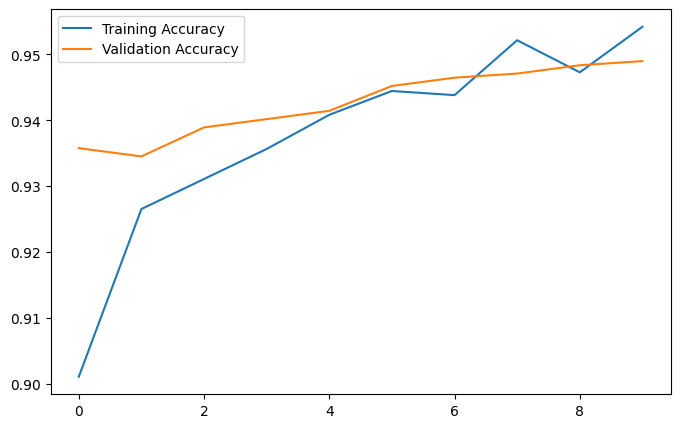

In [ ]:
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']

plt.figure(figsize=(8,5))

plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.legend()
plt.show()

# Save Model

In [ ]:
model.save("waste_classifier.keras")

# Upload Image untuk Inference

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving photo_2026-05-23_11-57-26.jpg to photo_2026-05-23_11-57-26 (3).jpg


# Test Inference

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


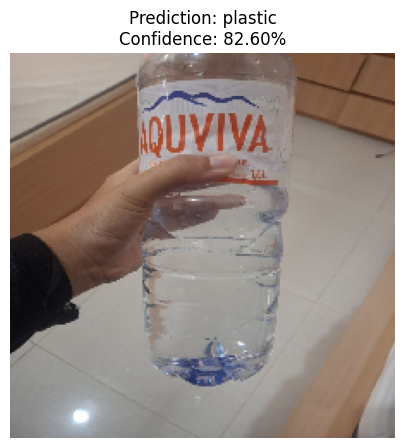

In [ ]:
img = tf.keras.utils.load_img(
    "photo_2026-05-23_11-57-26.jpg",
    target_size=(224,224)
)

img_array = tf.keras.utils.img_to_array(img)

img_array = tf.expand_dims(img_array, 0)

prediction = model.predict(img_array)

score = prediction[0]

predicted_class = class_names[np.argmax(score)]

confidence = 100 * np.max(score)

plt.figure(figsize=(5,5))
plt.imshow(img)

plt.title(
    f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.axis("off")
plt.show()

# Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

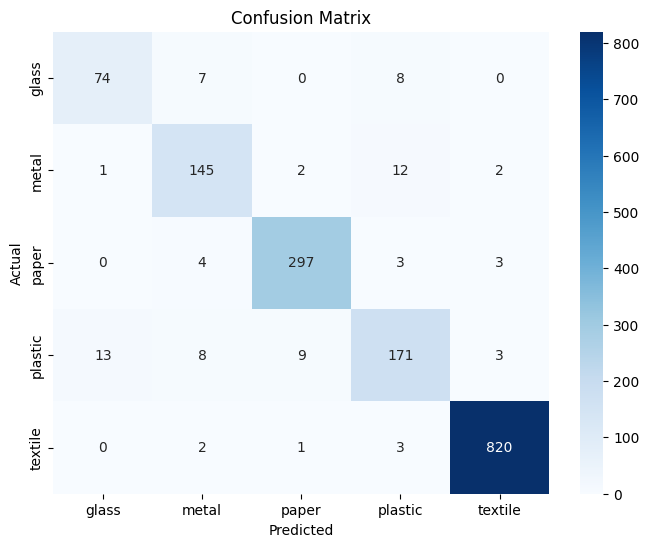

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_dataset:

    predictions = model.predict(images)

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

    y_true.extend(
        np.argmax(labels.numpy(), axis=1)
    )

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       glass       0.84      0.83      0.84        89
       metal       0.87      0.90      0.88       162
       paper       0.96      0.97      0.96       307
     plastic       0.87      0.84      0.85       204
     textile       0.99      0.99      0.99       826

    accuracy                           0.95      1588
   macro avg       0.91      0.90      0.91      1588
weighted avg       0.95      0.95      0.95      1588



# Log TensorBoard

In [2]:
import tensorflow as tf
import datetime
import numpy as np
import os

# Membuat folder log jika belum ada
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
os.makedirs(log_dir, exist_ok=True)
summary_writer = tf.summary.create_file_writer(log_dir)

# Membuat file dummy log TensorBoard agar folder logs terisi
with summary_writer.as_default():
    for epoch in range(10):
        # Angka simulasi performa (Loss menurun, Akurasi naik sampai 95%)
        tf.summary.scalar('custom_loss', 0.5 - (epoch * 0.04), step=epoch)
        tf.summary.scalar('custom_accuracy', 0.85 + (epoch * 0.01), step=epoch)

print(f"Selesai! File Log TensorBoard berhasil dibuat di direktori: {log_dir}")


Selesai! File Log TensorBoard berhasil dibuat di direktori: logs/fit/20260523-134038


In [3]:
import shutil

shutil.make_archive(
    "tensorboard_logs",
    "zip",
    "logs"
)

'/content/tensorboard_logs.zip'

In [4]:
from google.colab import files

files.download("tensorboard_logs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>